In [15]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import tensorflow as tf
import logging
tf.get_logger().setLevel('ERROR')

import shutil
from matplotlib import pyplot as plt
import numpy as np
from PIL import Image
import pandas as pd
import seaborn as sns
import glob
import pathlib as Path

import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="keras")

In [5]:
base_path = "/kaggle/input/competitions/anime-gender-classification/dataset"

train_data = os.path.join(base_path, "train_images")
test_data = os.path.join(base_path, "test_images")
val_data = os.path.join(base_path, "val_images")

kombine_data = "/kaggle/working/processed_dataset"
os.makedirs(kombine_data, exist_ok=True)


In [6]:
for category in os.listdir(train_data):
    category_dir = os.path.join(train_data, category)
    if os.path.isdir(category_dir):
	      shutil.copytree(category_dir, os.path.join(kombine_data, category), dirs_exist_ok=True)

	
for category in os.listdir(test_data):
    category_dir = os.path.join(test_data, category)
    if os.path.isdir(category_dir):
	      shutil.copytree(category_dir, os.path.join(kombine_data, category), dirs_exist_ok=True)


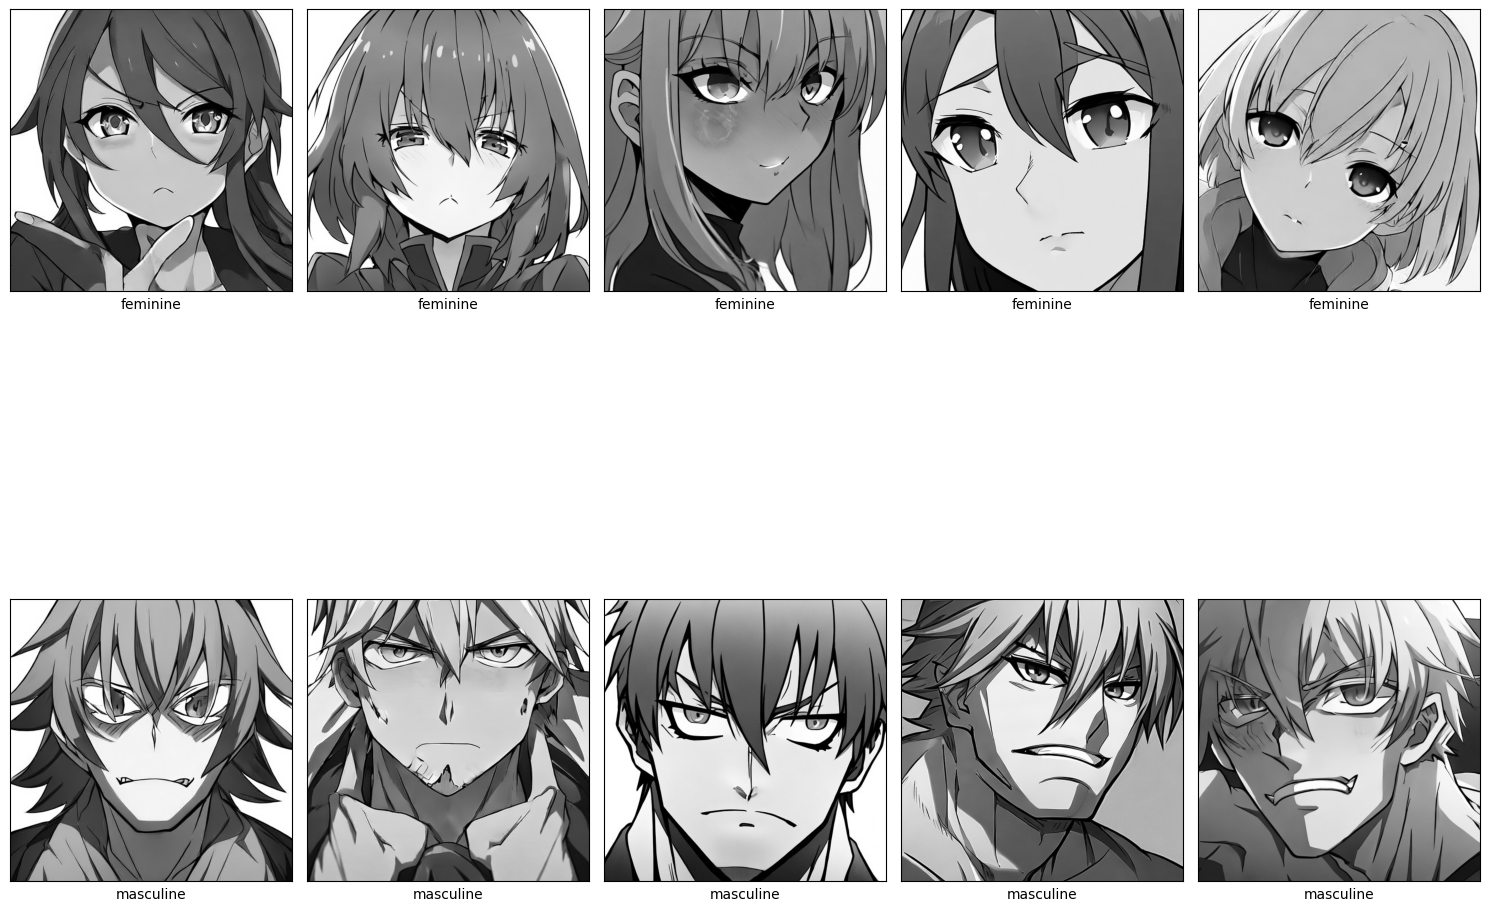

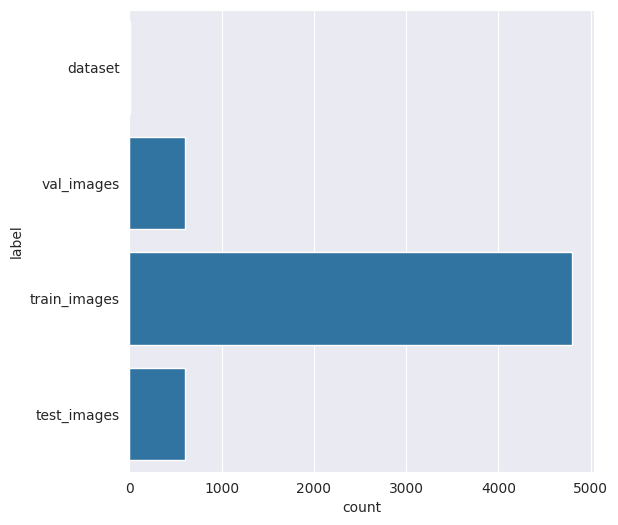

In [8]:
combined_dataset_root = "/kaggle/input/competitions/anime-gender-classification/dataset"

images_directory_train = os.path.join(combined_dataset_root, "train_images")
images_directory_val = os.path.join(combined_dataset_root, "val_images")


all_image_filenames_train = os.listdir(images_directory_train)
all_image_filenames_val = os.listdir(images_directory_val)


m_image = [f for f in all_image_filenames_train if f.startswith('masculine')]
f_image = [f for f in all_image_filenames_train if f.startswith('feminine')]

m_image_val = [f for f in all_image_filenames_val if f.startswith('masculine')]
f_image_val = [f for f in all_image_filenames_val if f.startswith('feminine')]


lung_image = {
    "feminine": f_image,
    "masculine": m_image
}

lung_image_val = {
    "feminime":f_image_val,
    "masculine":m_image_val
}
num_rows = len(lung_image.keys())


fig, axs = plt.subplots(num_rows, 5, figsize=(15, 15))

for i, class_name in enumerate(lung_image.keys()):
   
    selected_images = np.random.choice(lung_image[class_name], min(5, len(lung_image[class_name])), replace=False)

   
    current_axs_row = axs if num_rows == 1 else axs[i]

    for j, image_name in enumerate(selected_images):
        img_path = os.path.join(images_directory_train, image_name)
        img = Image.open(img_path).convert("L")  
        current_axs_row[j].imshow(img, cmap='gray')
        current_axs_row[j].set(xlabel=class_name, xticks=[], yticks=[])

fig.tight_layout()

lung_path = "/kaggle/input/competitions/anime-gender-classification/dataset"

file_name = []
label = []
full_path = []

for path,subdirs,files in os.walk(lung_path):
  for name in files:
    full_path.append(os.path.join(path,name))
    label.append(path.split('/')[-1])
    file_name.append(name)

distribusi_data = pd.DataFrame({"path":full_path,"file_name":file_name,"label":label})

label = distribusi_data["label"]
plt.figure(figsize=(6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(label)

In [9]:
distribusi_data = pd.DataFrame({"path":full_path,"file_name":file_name,"label":label})
train_images = distribusi_data[distribusi_data['label'] == "train_images"]
train_images.head(10)
train_images.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4800 entries, 604 to 5403
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   path       4800 non-null   object
 1   file_name  4800 non-null   object
 2   label      4800 non-null   object
dtypes: object(3)
memory usage: 150.0+ KB


In [17]:
from pathlib import Path
images_folder = Path("/kaggle/input/competitions/anime-gender-classification/dataset/test_images")

rows = []
for img_path in sorted(images_folder.glob("*")):
    if img_path.is_file() and img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
        rows.append({
            "filepath": str(img_path),
            "filename": img_path.name
        })

df_test = pd.DataFrame(rows)
print(df_test.shape)
df_test.head()

(600, 2)


,filepath,filename
0,/kaggle/input/competitions/anime-gender-classi...,img_000001.jpg
1,/kaggle/input/competitions/anime-gender-classi...,img_000002.jpg
2,/kaggle/input/competitions/anime-gender-classi...,img_000003.jpg
3,/kaggle/input/competitions/anime-gender-classi...,img_000004.jpg
4,/kaggle/input/competitions/anime-gender-classi...,img_000005.jpg


In [19]:
def dict_to_df(mapping_dict, images_dir):
    rows = []
    for gender_key, files in mapping_dict.items():
        for f in files:
            p = os.path.join(images_dir, f)
            label = "male" if gender_key=="masculine" else "female" 
            rows.append({ "filepath": p, "filename": f, "label": label})
    return pd.DataFrame(rows)

train_df = dict_to_df(lung_image, "/kaggle/input/competitions/anime-gender-classification/dataset/train_images")
val_df   = dict_to_df(lung_image_val,   "/kaggle/input/competitions/anime-gender-classification/dataset/val_images")


test_folder = Path("/kaggle/input/competitions/anime-gender-classification/dataset/test_images")

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
rows = []

for p in sorted(test_folder.rglob("*")):
    if p.is_file() and p.suffix.lower() in image_exts:
        if p.parent == test_folder:
            label = "unknown"   
        else:
            label = p.parent.name

        rows.append({
            "filepath": str(p),
            "filename": p.name,
        })

test_df = pd.DataFrame(rows, columns=["filepath", "filename", "label"])

try:
    print("\nTrain set distribution:")
    print(len(train_df["label"]))
    print(train_df["label"].value_counts())
    print("\nValidation set distribution:")
    print(len(val_df["label"]))
    print(val_df["label"].value_counts())
    print("\nTest set distribution:")
    print(len(test_df["filename"]))
    print(test_df["filename"].value_counts())

except Exception as e:
    print(f"error during train_test_split")


Train set distribution:
4800
label
male      2418
female    2382
Name: count, dtype: int64

Validation set distribution:
600
label
female    313
male      287
Name: count, dtype: int64

Test set distribution:
600
filename
img_000600.jpg    1
img_000001.jpg    1
img_000002.jpg    1
img_000003.jpg    1
img_000004.jpg    1
                 ..
img_000028.jpg    1
img_000029.jpg    1
img_000030.jpg    1
img_000031.jpg    1
img_000032.jpg    1
Name: count, Length: 600, dtype: int64


In [20]:
dagen = ImageDataGenerator()

train_gen = dagen.flow_from_dataframe(
    dataframe= train_df,
    x_col ="filepath",
    y_col = "label",
    target_size = (128,128),
    color_mode = "grayscale",
    class_mode = "binary",
    classes = ["male","female"],
    batch_size = 32,
    shuffle = True
)

val_gen = dagen.flow_from_dataframe(
    dataframe= val_df,
    x_col ="filepath",
    y_col = "label",
    target_size = (128,128),
    color_mode = "grayscale",
    class_mode = "binary",
    classes = ["male","female"],
    batch_size = 32,
    shuffle = False
)

test_gen = dagen.flow_from_dataframe(
    dataframe= test_df,
    x_col ="filepath",
    y_col = None,
    target_size = (128,128),
    color_mode = "grayscale",
    class_mode = None,
    classes = None,
    batch_size = 1,
    shuffle = False
)

Found 4800 validated image filenames belonging to 2 classes.
Found 600 validated image filenames belonging to 2 classes.
Found 600 validated image filenames.


In [22]:
model = Sequential()

model.add(Conv2D(32, (3,3),padding="same", activation="relu", input_shape=(128,128,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(32, (4,4),padding="same", activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(32, (7,7),padding="same", activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(1, activation="sigmoid"))

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │        50,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,124,353 (4.29 MB)

 Trainable params: 1,124,161 (4.29 MB)

 Non-trainable params: 192 (768.00 B)

None


In [24]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)
Early= EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)
train_model = model.fit(
    train_gen,
    epochs=20,
    batch_size=32,
    validation_data=val_gen,
    callbacks= [reduce_lr,Early]
)

Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 57s 381ms/step - accuracy: 0.5867 - loss: 0.9831 - val_accuracy: 0.7817 - val_loss: 0.4648 - learning_rate: 0.0010
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - accuracy: 0.7500 - loss: 0.4984 - val_accuracy: 0.8567 - val_loss: 0.3246 - learning_rate: 0.0010
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - accuracy: 0.8322 - loss: 0.3614 - val_accuracy: 0.8817 - val_loss: 0.2599 - learning_rate: 0.0010
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 19s 124ms/step - accuracy: 0.8842 - loss: 0.2715 - val_accuracy: 0.8433 - val_loss: 0.3607 - learning_rate: 0.0010
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 19s 127ms/step - accuracy: 0.9153 - loss: 0.2113 - val_accuracy: 0.9167 - val_loss: 0.2033 - learning_rate: 0.0010
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - accuracy: 0.9385 - loss: 0.1621 - val_accuracy: 0.9233 - val_loss: 0.1735 - learning_rate: 0.0010
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - accuracy: 0.9



              precision    recall  f1-score   support

        male     0.9604    0.9303    0.9451       287
      female     0.9379    0.9649    0.9512       313

    accuracy                         0.9483       600
   macro avg     0.9492    0.9476    0.9482       600
weighted avg     0.9487    0.9483    0.9483       600



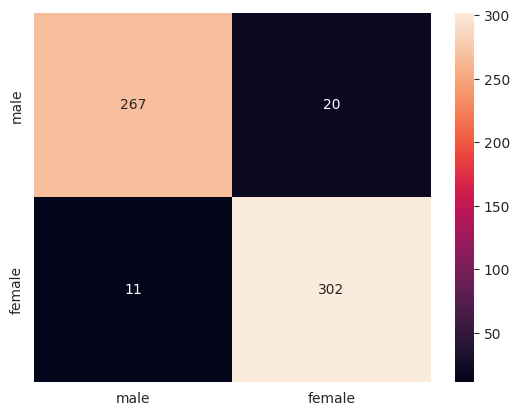

In [25]:
val_gen.reset()

pred = model.predict(val_gen,verbose=0)
pred = pred.copy()
pred[pred <= 0.5] = 0
pred[pred > 0.5] = 1


class_mapping = val_gen.class_indices

sorted_class_names = [k for k, v in sorted(class_mapping.items(), key=lambda item: item[1])]
sorted_numerical_labels = [v for k, v in sorted(class_mapping.items(), key=lambda item: item[1])]

cm = pd.DataFrame(data=confusion_matrix(val_gen.classes, pred, labels=sorted_numerical_labels),
                  index=sorted_class_names,
                  columns=sorted_class_names)
sns.heatmap(cm,annot=True,fmt="d")

print("\n")
print(classification_report(y_true=val_gen.classes,y_pred=pred,target_names=sorted_class_names, digits=4))


In [26]:
test_gen.reset()

pred = model.predict(test_gen, verbose=1)
pred = pred.copy()
pred[pred <= 0.5] = 0
pred[pred > 0.5] = 1

labels = pred.flatten().astype(int)


filenames = test_gen.filenames
ids = [os.path.splitext(os.path.basename(x))[0] for x in filenames]


pred_df = pd.DataFrame({'id': ids, 'label': labels})


df_format = pd.read_csv("/kaggle/input/competitions/anime-gender-classification/dataset/submission_format.csv")

df_format['id'] = df_format['id'].astype(str).str.strip()
pred_df['id'] = pred_df['id'].astype(str).str.strip() + ".jpg"

result_df = pd.merge(df_format[['id']], pred_df, on='id', how='left')
result_df.head()


if result_df['label'].isnull().any():
    missing_ids = result_df[result_df['label'].isnull()]['id']
    print(len(missing_ids))

result_df.to_csv("submission_final.csv", index=False)
from IPython.display import FileLink
FileLink(r"submission_final.csv")

model.save("model_predik_anime.h5")
FileLink(r"model_predik_anime.h5")
print("model berhasil di simpan")

600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step


model berhasil di simpan
